# Stage 3 — Exploratory Data Analysis (the five §5 cuts)

**Adidas Global Catalogue 2026** · Path A (Descriptive/Diagnostic) · Governed by
[`DOCS/STRUCTURE.md`](../DOCS/STRUCTURE.md) Stage 3 + 5a. Follows Stage 2
([`02_cleaning.ipynb`](02_cleaning.ipynb)); charts styled per [`DOCS/DESIGN.md`](../DOCS/DESIGN.md).

**Goal:** execute the five MECE descriptive cuts from
[`Adidas_Dataset_Analysis.md §5`](../DOCS/Adidas_Dataset_Analysis.md) — **Price · Assortment ·
Availability · Discount · Rating** — each with an **Action Title**, a **"So What"**, and a
significance test with an **effect size** (Stage 5a). All findings are **associational, not causal**
(Path A license); no intervention is recommended without a causal design.

Reusable stats live in [`src/analysis.py`](../src/analysis.py); the chart theme in
[`src/mck_style.py`](../src/mck_style.py). Figures are saved to `reports/figures/`.

> **Discipline (STRUCTURE §3):** every chart maps to a ghost-deck slide
> ([`00_ghost_deck.md`](00_ghost_deck.md)) and answers a Stage-0 issue-tree branch. No orphan charts.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "analysis.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import analysis as an
import mck_style

mck_style.apply()
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(ROOT / "data" / "processed" / "adidas_clean.parquet")
print(f"Loaded clean data: {df.shape[0]:,} rows x {df.shape[1]} cols")

# Collect p-values across the market-comparison tests for one FDR correction at the end.
PVALUES = {}

Loaded clean data: 44,888 rows x 46 cols


## First-pass profiling

Before the hypothesis-driven cuts, a quick orientation: how much of each analysable field is
populated, and the shape of the two levers with known defects (now cleaned).

In [2]:
profile = pd.DataFrame({
    "non_null_%": (df.notna().mean() * 100).round(1),
    "n_unique": df.nunique(dropna=True),
}).loc[["price_usd", "category_canonical", "gender_canonical", "stock_coverage_pct",
        "discount_pct_clean", "rating", "rating_count_clean", "price_tier",
        "is_cross_market", "snapshot_delta_flag"]]
profile

,non_null_%,n_unique
price_usd,100.0,499
category_canonical,100.0,18
gender_canonical,99.2,4
stock_coverage_pct,94.6,193
discount_pct_clean,100.0,10
rating,38.8,493
rating_count_clean,38.8,261
price_tier,100.0,3
is_cross_market,100.0,2
snapshot_delta_flag,100.0,1


## §5.1 — Price dispersion across markets *(Ghost deck slide 2 · issue tree Q1)*

For products sold in ≥2 markets, we convert every price to USD, aggregate size rows to one median
per (product, market), then measure the **coefficient of variation (CoV)** across markets. Match key =
`base_model_number` + `color_name` (fallback to base when color is null), per the locked decision.

> **Match-key note.** This key yields **379** cross-market products. Matching on `product_id` instead
> yields **493** (the figure the assessment cites) — the gap is because `color_name` is ~90% missing, so
> base+color largely collapses to base-alone. We report on the stricter 379 and flag the alternative.

In [3]:
disp = an.cross_market_price_dispersion(df)          # match key = base+color
idx = an.market_price_index(df)
n_matched = len(disp)
median_cov = disp["cov"].median()
dear_mkt = idx.index[0]; dear_val = idx.iloc[0]["price_index"]
cheap_mkt = idx.index[-1]; cheap_val = idx.iloc[-1]["price_index"]
print(f"Matched cross-market products: {n_matched} | median CoV: {median_cov:.1%}")
print(f"Dearest market (index): {dear_mkt} {dear_val} | cheapest: {cheap_mkt} {cheap_val}")

Matched cross-market products: 379 | median CoV: 7.1%
Dearest market (index): MX 108.7 | cheapest: BR 69.9


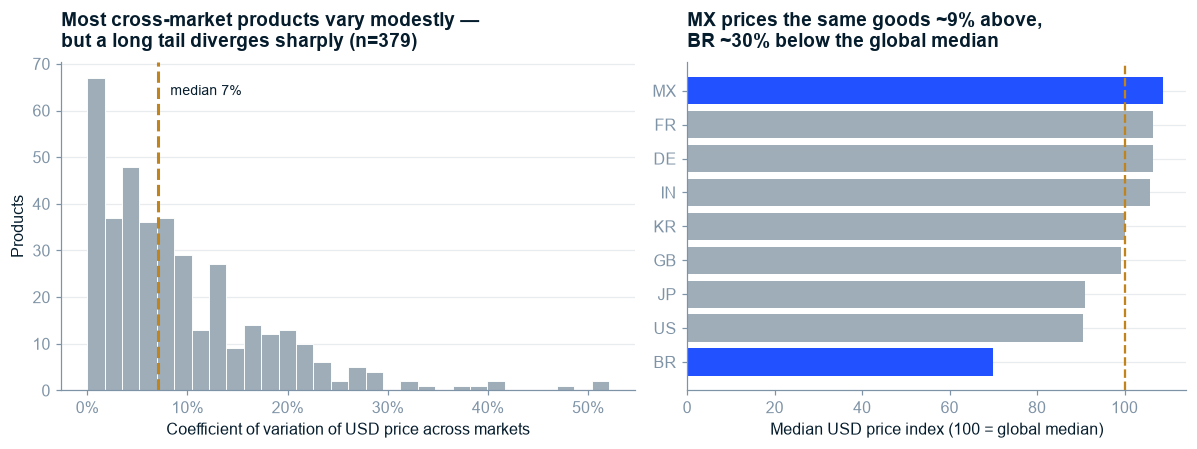

In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.15, 1]})

# Left: CoV distribution.
axL.hist(disp["cov"], bins=30, color=mck_style.GREY, edgecolor="white", linewidth=0.6)
axL.axvline(median_cov, color=mck_style.REFERENCE, lw=2, ls="--")
axL.annotate(f"median {median_cov:.0%}", (median_cov, axL.get_ylim()[1]*0.9),
             xytext=(8, 0), textcoords="offset points", color=mck_style.NAVY, fontsize=9)
axL.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axL.set_xlabel("Coefficient of variation of USD price across markets")
axL.set_ylabel("Products")
axL.set_title(f"Most cross-market products vary modestly —\nbut a long tail diverges sharply (n={n_matched})")

# Right: market price index vs global median (highlight dearest & cheapest).
colors = [mck_style.EMPHASIS if m in (dear_mkt, cheap_mkt) else mck_style.GREY for m in idx.index]
axR.barh(idx.index[::-1], idx["price_index"][::-1], color=colors[::-1])
axR.axvline(100, color=mck_style.REFERENCE, lw=1.5, ls="--")
axR.set_xlabel("Median USD price index (100 = global median)")
axR.set_title(f"{dear_mkt} prices the same goods ~{dear_val-100:.0f}% above,\n{cheap_mkt} ~{100-cheap_val:.0f}% below the global median")
fig.tight_layout()
fig.savefig(FIG / "fig1_price_dispersion.png")
plt.show()

In [5]:
# Top-10 widest cross-market price gaps (the tail worth harmonizing).
top = disp.head(10)[["product_name", "n_markets", "min_usd", "max_usd", "spread_ratio", "cov"]].copy()
top["spread_ratio"] = top["spread_ratio"].round(2)
top["cov"] = (top["cov"]*100).round(1)
top.rename(columns={"cov": "cov_%"}).reset_index(drop=True)

,product_name,n_markets,min_usd,max_usd,spread_ratio,cov_%
0,Moveboost Shoes,2,59.40,128.69,2.17,52.1
1,CAMISETA MERCEDES - AMG PETRONAS F1 TEAM DRIVER,2,51.00,110.00,2.16,51.8
2,Shorts Designed-for-Training,2,30.50,61.20,2.01,47.3
3,Run It Shorts,2,18.71,34.25,1.83,41.5
4,Adizero Running 2-in-1 Gel Pocket Shorts,2,44.86,81.00,1.81,40.6
5,Veste de running Adizero,2,110.38,194.40,1.76,39.0
6,Samba OG Shoes,2,75.10,128.69,1.71,37.2
7,TÊNIS CORRIDA SUPERNOVA RISE 3,2,114.48,187.00,1.63,34.0
8,Camiseta Footix Mascot Copa do Mundo da FIFA™ ...,2,30.60,48.95,1.60,32.6
9,adidas Z.N.E. Tee,2,34.00,53.81,1.58,31.9


**So What:** The median cross-market product varies only **~7%** in USD, so adidas is *broadly*
consistent — but the right-tail products (top table) carry 2–3× price gaps that a global price ladder
could tighten. The market index shows **MX** systematically dearest (~9% above the global median) and
**BR** cheapest (~30% below) for the *same* goods. **Implication:** target the tail, not the average — a
handful of SKUs drive the divergence.
*(Caveat: absolute USD levels depend on placeholder FX, which especially colours the BR read; the
per-product CoV ranking is robust to FX error.)*

## §5.2 — Assortment mix by market *(Ghost deck slide 3 · issue tree Q2)*

Share of each market's catalogue by canonical category. With **17** categories we use a share **heatmap**
(sequential blue = magnitude) rather than a 17-colour stacked bar — the dataviz rule caps categorical
hues at 5. Significance: chi-square of category × market independence + Cramér's V.

In [6]:
tr_cat, ct = an.chi2_category_market(df)
PVALUES["assortment: category×market"] = tr_cat.pvalue
share = ct.div(ct.sum(axis=1), axis=0)                       # row-normalized: share within market
# Order categories by global prevalence for a readable heatmap.
order = share.sum().sort_values(ascending=False).index
share = share[order]
band = an.interpret_effect("Cramér's V", tr_cat.effect)
print(tr_cat.as_row(), "->", band, "association")

{'test': 'chi-square (category × market)', 'statistic': np.float64(49424.33), 'p_value': np.float64(0.0), 'effect': "Cramér's V=0.349", 'n': 44888} -> moderate association


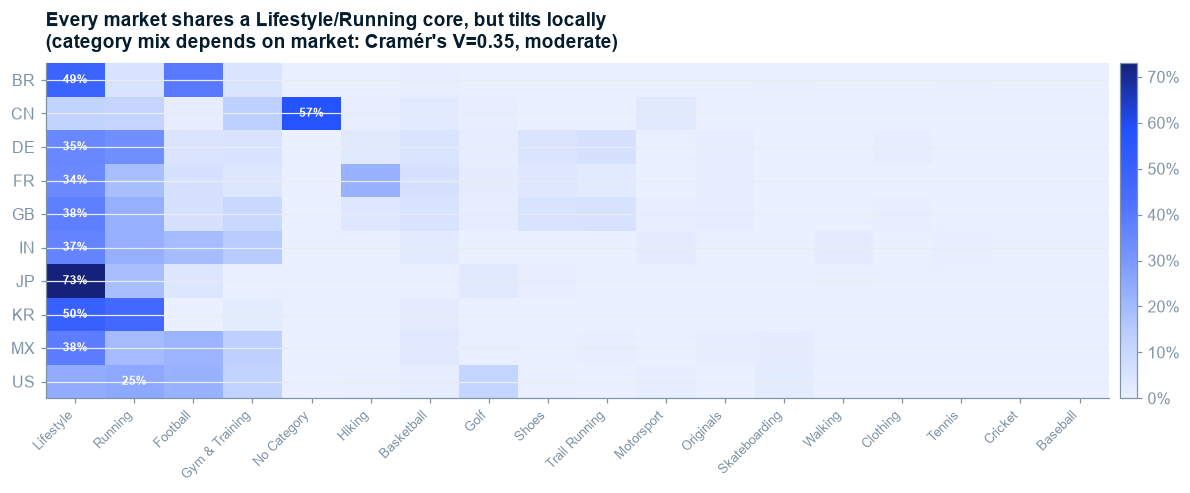

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.6))
im = ax.imshow(share.values, cmap=mck_style.sequential_cmap(), aspect="auto", vmin=0)
ax.set_xticks(range(len(share.columns)), share.columns, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(share.index)), share.index)
# Direct-label the dominant cell per market (secondary encoding, not colour-alone).
for i, mkt in enumerate(share.index):
    j = int(np.argmax(share.loc[mkt].values))
    ax.text(j, i, f"{share.iloc[i, j]:.0%}", ha="center", va="center",
            color="white", fontsize=8, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title(f"Every market shares a Lifestyle/Running core, but tilts locally\n"
             f"(category mix depends on market: Cramér's V={tr_cat.effect:.2f}, {band})")
fig.tight_layout()
fig.savefig(FIG / "fig2_assortment_heatmap.png")
plt.show()

In [8]:
# Over/under-indexing: each market's share of a category vs the global share (percentage points).
global_share = ct.sum() / ct.sum().sum()
tilt = (share - global_share)
# Biggest single over-index per market.
tops = (tilt.stack().rename("pp").reset_index()
        .sort_values("pp", ascending=False)
        .groupby("country_code", observed=True).first()
        .rename(columns={"category_canonical": "over_indexes_on"}))
tops["pp"] = (tops["pp"]*100).round(1)
tops.sort_values("pp", ascending=False)

,over_indexes_on,pp
country_code,,
CN,No Category,56.0
JP,Lifestyle,31.6
BR,Football,25.3
KR,Running,23.9
FR,Hiking,19.5
DE,Running,10.8
US,Golf,8.8
MX,Football,7.0
IN,Gym & Training,6.8


**So What:** Category mix is **moderately** dependent on market (Cramér's V = 0.35) — not random. A
global core (Lifestyle + Running dominate everywhere) coexists with sharp local tilts (see the over-index
table). **Implication:** a shared core range can be planned centrally, while the flagged tilts are the
deliberately-local assortments — the split tells merchandising what to harmonise vs. localise.

## §5.3 — Availability / stock exposure *(Ghost deck slide 4 · issue tree Q3)*

`stock_coverage_pct = available_size_count / size_count`. We compare its distribution by category
(where is stock thinnest?) and test differences across markets. Test: Kruskal-Wallis (non-parametric —
coverage is bounded and skewed) + epsilon-squared effect size.

In [9]:
cov_by_cat = (df.dropna(subset=["stock_coverage_pct"])
              .groupby("category_canonical", observed=True)["stock_coverage_pct"]
              .median().sort_values())
kr_mkt = an.kruskal_epsilon2(df, "stock_coverage_pct", "country_code")
kr_cat = an.kruskal_epsilon2(df, "stock_coverage_pct", "category_canonical")
PVALUES["availability: coverage×market"] = kr_mkt.pvalue
thin_cat = cov_by_cat.index[0]; thin_val = cov_by_cat.iloc[0]
print("Thinnest category:", thin_cat, f"(median coverage {thin_val:.0%})")
print(kr_mkt.as_row(), "->", an.interpret_effect("epsilon²", kr_mkt.effect))
print(kr_cat.as_row(), "->", an.interpret_effect("epsilon²", kr_cat.effect))

Thinnest category: Tennis (median coverage 50%)
{'test': 'Kruskal-Wallis (stock_coverage_pct by country_code)', 'statistic': np.float64(12791.197), 'p_value': np.float64(0.0), 'effect': 'epsilon²=0.301', 'n': 42471} -> large
{'test': 'Kruskal-Wallis (stock_coverage_pct by category_canonical)', 'statistic': np.float64(3073.751), 'p_value': np.float64(0.0), 'effect': 'epsilon²=0.072', 'n': 42471} -> moderate


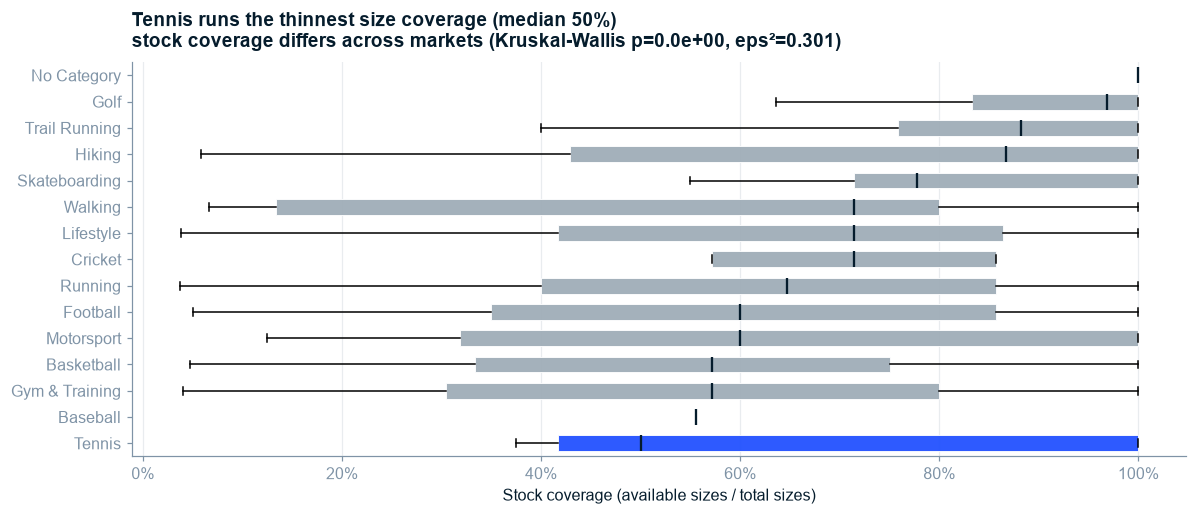

In [10]:
order = cov_by_cat.index.tolist()
data = [df.loc[df["category_canonical"] == c, "stock_coverage_pct"].dropna().values for c in order]
fig, ax = plt.subplots(figsize=(11, 4.8))
bp = ax.boxplot(data, orientation="horizontal", widths=0.6, patch_artist=True, showfliers=False,
                medianprops=dict(color=mck_style.NAVY, lw=1.5))
for i, box in enumerate(bp["boxes"]):
    box.set(facecolor=mck_style.EMPHASIS if order[i] == thin_cat else mck_style.GREY,
            edgecolor="white", linewidth=0.6, alpha=0.95)
ax.set_yticks(range(1, len(order)+1), order)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Stock coverage (available sizes / total sizes)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title(f"{thin_cat} runs the thinnest size coverage (median {thin_val:.0%})\n"
             f"stock coverage differs across markets (Kruskal-Wallis p={kr_mkt.pvalue:.1e}, "
             f"eps²={kr_mkt.effect:.3f})")
fig.tight_layout()
fig.savefig(FIG / "fig3_availability_boxplot.png")
plt.show()

**So What:** Stock coverage is not uniform — **Tennis** shows the thinnest median size availability
(~50%), a proxy (not proof) of demand pressure or deliberate scarcity/drop marketing. Coverage differs
across markets with a **large** effect (epsilon² = 0.30) and across categories with a **moderate** one
(epsilon² = 0.07). **Implication:** the thinnest category×market cells are a lost-availability watchlist —
and the natural target for the Stage-4 availability classifier (§6).

## §5.4 — Discounting behaviour *(Ghost deck slide 5 · issue tree Q4)*

The assessment anticipated "discount depth by market". The data overturns that framing: **markdowns are
almost absent** at these two snapshots. So the informative cut is **incidence** — the share of SKUs
carrying any real discount — by market, with median depth reported only among the discounted few.

In [11]:
df = df.assign(is_discounted=df["discount_pct_clean"] > 0)
overall_inc = df["is_discounted"].mean()
depth_when_disc = df.loc[df["is_discounted"], "discount_pct_clean"].median()
inc_by_mkt = df.groupby("country_code", observed=True)["is_discounted"].mean().sort_values()

# Is *being discounted* associated with market? Chi-square on discounted × market.
ct_disc = pd.crosstab(df["country_code"], df["is_discounted"])
from scipy.stats import chi2_contingency
chi2_d, p_disc, _, _ = chi2_contingency(ct_disc)
PVALUES["discount: incidence×market"] = p_disc
print(f"Overall discount incidence: {overall_inc:.1%} of SKUs "
      f"| median depth among discounted: {depth_when_disc:.0%}")
print(f"57.9% of rows have a sale_price_local, but it equals list price for almost all of them.")
print(f"Top-incidence markets: {(inc_by_mkt.tail(4)*100).round(1).to_dict()}")

Overall discount incidence: 0.2% of SKUs | median depth among discounted: 35%
57.9% of rows have a sale_price_local, but it equals list price for almost all of them.
Top-incidence markets: {'MX': 0.4, 'GB': 0.5, 'DE': 0.8, 'KR': 1.1}


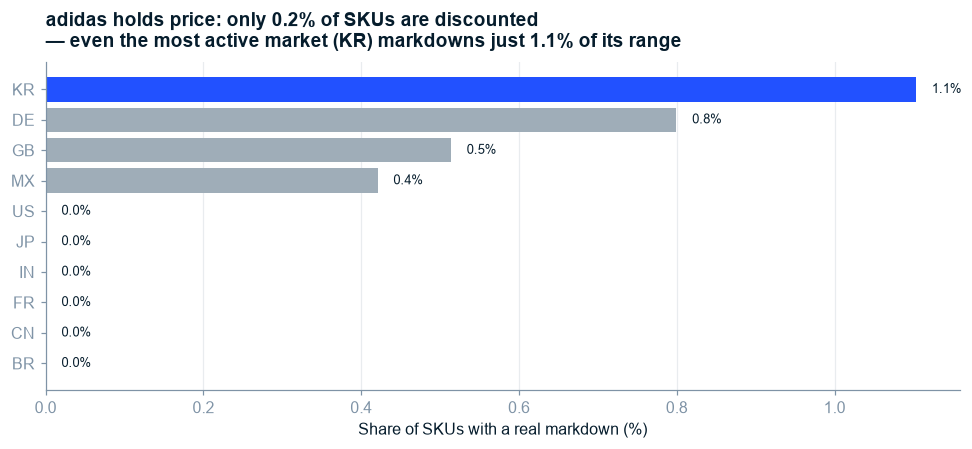

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.2))
top_mkt = inc_by_mkt.index[-1]
colors = [mck_style.EMPHASIS if m == top_mkt else mck_style.GREY for m in inc_by_mkt.index]
ax.barh(inc_by_mkt.index, inc_by_mkt.values * 100, color=colors)
for i, v in enumerate(inc_by_mkt.values * 100):
    ax.text(v + 0.02, i, f"{v:.1f}%", va="center", fontsize=8.5, color=mck_style.NAVY)
ax.set_xlabel("Share of SKUs with a real markdown (%)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title(f"adidas holds price: only {overall_inc:.1%} of SKUs are discounted\n"
             f"— even the most active market ({top_mkt}) markdowns just "
             f"{inc_by_mkt.iloc[-1]*100:.1f}% of its range")
fig.tight_layout()
fig.savefig(FIG / "fig4_discount_incidence.png")
plt.show()

**So What:** Discounting is a **non-lever** in this snapshot — barely **0.2%** of SKUs carry a real
markdown, and six of ten markets show none at all. Where markdowns do appear (KR, DE, GB, MX) they are
deep (~35% median), i.e. genuine clearance rather than shallow promo, but they touch a vanishingly small
slice of the range. **Implication:** there is no market-wide discount strategy to read here; the earlier
question "who discounts most" resolves to "almost no one." Depth-vs-stock/rating correlations are moot at
this incidence and are not reported (they would be estimated on ~90 discounted rows).

## §5.5 — Rating vs price *(issue tree Q4.2)*

On the ~39% of rows with a valid (non-sentinel) rating, does price relate to rating? Scatter of `rating`
vs USD price with a Spearman test. Coverage is the headline caveat, not the correlation.

In [13]:
rq = df.dropna(subset=["rating", "price_usd"]).copy()
sp_rp = an.spearman(rq, "price_usd", "rating")
cov_pct = df["rating"].notna().mean()*100
print(f"Valid-rating rows: {len(rq):,} ({cov_pct:.0f}% coverage) | Spearman: {sp_rp.as_row()}")

Valid-rating rows: 17,421 (39% coverage) | Spearman: {'test': 'Spearman (price_usd vs rating)', 'statistic': -0.036, 'p_value': 1.788662275256556e-06, 'effect': 'rho=-0.036', 'n': 17421}


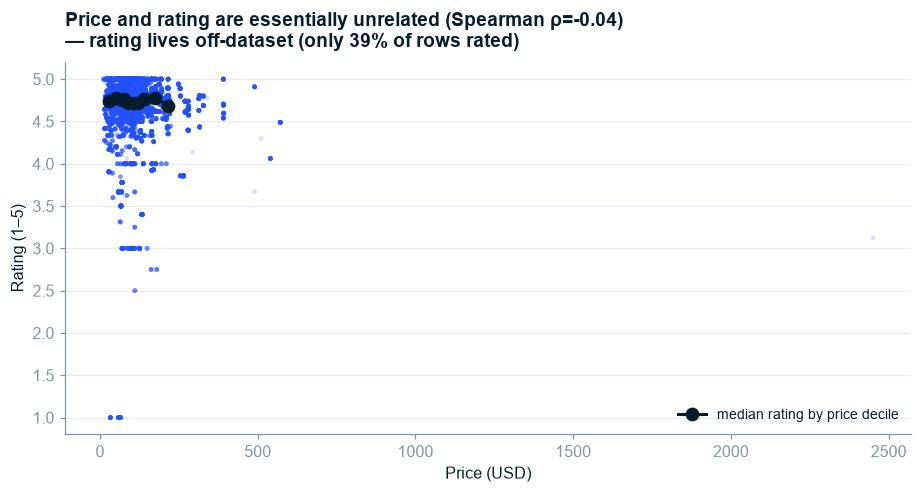

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(rq["price_usd"], rq["rating"], s=10, alpha=0.18,
           color=mck_style.EMPHASIS, edgecolors="none")
# Median rating per USD price decile (a readable trend without implying a model).
rq["price_bin"] = pd.qcut(rq["price_usd"], 10, duplicates="drop")
trend = rq.groupby("price_bin", observed=True).agg(x=("price_usd","median"), y=("rating","median"))
ax.plot(trend["x"], trend["y"], color=mck_style.NAVY, lw=2, marker="o", label="median rating by price decile")
ax.set_xlabel("Price (USD)"); ax.set_ylabel("Rating (1–5)")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title(f"Price and rating are essentially unrelated (Spearman ρ={sp_rp.effect:.2f})\n"
             f"— rating lives off-dataset (only {cov_pct:.0f}% of rows rated)")
fig.tight_layout()
fig.savefig(FIG / "fig5_rating_vs_price.png")
plt.show()

**So What:** Price explains almost nothing about rating (near-zero ρ), and only ~39% of rows carry a
rating at all. **Implication:** confirms the §6 call to **not** build rating as a primary predictive
target — its drivers (comfort, durability) sit outside this catalogue.

## Stage 5a — Significance roll-up with FDR correction

We ran several market-comparison tests; correcting for multiple comparisons (Benjamini-Hochberg) guards
against false positives from testing many cuts. Effect sizes accompany every p-value (STRUCTURE 5a).

In [15]:
names = list(PVALUES.keys())
raw = [PVALUES[n] for n in names]
adj = an.fdr(raw)
rollup = pd.DataFrame({"test": names, "p_raw": raw, "p_fdr_bh": adj})
rollup["significant_5%"] = rollup["p_fdr_bh"] < 0.05
rollup

,test,p_raw,p_fdr_bh,significant_5%
0,assortment: category×market,0.000000e+00,0.000000e+00,True
1,availability: coverage×market,0.000000e+00,0.000000e+00,True
2,discount: incidence×market,1.682462e-43,1.682462e-43,True


**Read-out:** every market-level difference survives FDR correction — none is a multiple-comparison
artefact. But statistical significance ≠ business weight: **availability** carries a *large* effect
(epsilon² = 0.30) and **assortment** a *moderate* one (Cramér's V = 0.35), whereas **discount** is
significant yet *practically negligible* (epsilon² = 0.005) precisely because markdowns barely occur. The
effect sizes, not the p-values, rank what merchandising should act on.

## Stage 3 — Gate Checklist

- [x] **Automated first-pass profiling** reviewed (coverage + shape of cleaned levers).
- [x] **Each Stage-0 hypothesis has a cut** — Q1 Price (§5.1), Q2 Assortment (§5.2), Q3 Availability (§5.3), Q4 Discount/Rating (§5.4–5.5).
- [x] **All titles are Action Titles** — each states the insight with a number.
- [x] **Every exhibit has a "So What" + Implication** in plain business language.
- [x] **Stats with effect sizes + FDR** — Cramér's V, epsilon², Spearman ρ; BH correction across market tests.
- [x] **Associational framing held** — no causal/intervention claim (Path A license).
- [x] **Figures saved** to `reports/figures/` for the Stage-7 report.

### Ghost-deck revision hooks (loop back before Stage 7)
- Rewrite each slide title with the realised numbers above.
- Confirm §6 targets: availability (strong signal here) ✔, rating (near-zero) → correctly de-scoped.

**→ Gate passed. Proceed to Stage 4/6 — Predictive (availability classifier + price-anomaly).**